## **EMOTION DATASET AND CNN MODEL**

Path to dataset files: /kaggle/input/fer2013
Dataset folder contents: ['test', 'train']
Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 140s 368ms/step - accuracy: 0.2416 - loss: 1.8213 - val_accuracy: 0.3327 - val_loss: 1.6623
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.3659 - loss: 1.6151 - val_accuracy: 0.4551 - val_loss: 1.4411
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.4410 - loss: 1.4442 - val_accuracy: 0.4872 - val_loss: 1.3406
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.4803 - loss: 1.3510 - val_accuracy: 0.5152 - val_loss: 1.2855
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.4968 - loss: 1.3067 - val_accuracy: 0.5318 - val_loss: 1.2618
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.5201 - loss: 1.2603 - val_accuracy: 0.5377 - val_loss: 1.2234
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5373 - loss: 1.2077 - val_accuracy: 0.5473 - val_loss: 1.1975
Epoch 8/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.5498 - loss: 1.1857 

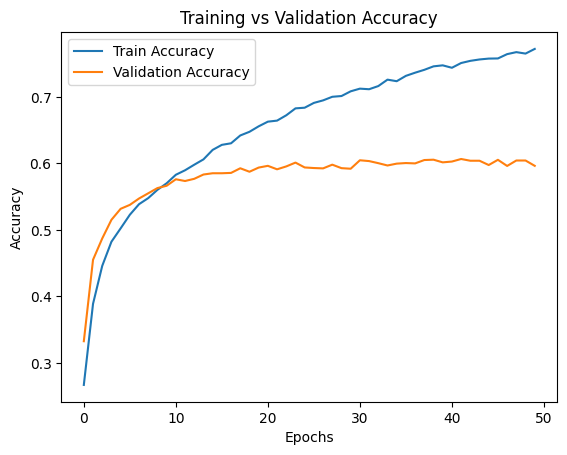

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import kagglehub
import os
import zipfile

# Download FER-2013 dataset from Kaggle
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)

# Extract dataset if it's in a zip file
zip_path = os.path.join(path, "fer2013.zip")
dataset_path = os.path.join(path, "fer2013")

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(path)
    print("Dataset extracted successfully.")

# Verify extracted contents
print("Dataset folder contents:", os.listdir(path))

# Adjust dataset path based on extracted contents
if "fer2013" in os.listdir(path):
    dataset_path = os.path.join(path, "fer2013")
elif "train" in os.listdir(path):
    dataset_path = path  # Already at correct structure
else:
    raise FileNotFoundError("Dataset folder structure is incorrect. Please check the extraction process.")

# Load FER-2013 dataset
data_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = data_gen.flow_from_directory(
    os.path.join(dataset_path, 'train'),
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

val_generator = data_gen.flow_from_directory(
    os.path.join(dataset_path, 'train'),
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

# CNN Model
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=50)

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

# Save the model
model.save('emotion_detector_model.h5')


In [ ]:
# Print final accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")


Final Training Accuracy: 77.22%
Final Validation Accuracy: 59.64%


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path where you want to save the model
model_save_path = "/content/drive/My Drive/emotion_detector_model.h5"

# Save model to Google Drive
model.save(model_save_path)

print(f"Model saved to: {model_save_path}")


Mounted at /content/drive
Model saved to: /content/drive/My Drive/emotion_detector_model.h5
